In [1]:
import pandas as pd
import numpy as np
import os

def filter_and_undersample(
    resmat: pd.DataFrame, 
    min_threshold: int, 
    max_nan_percent: float = 0.1,
    groups: list = None,
    output_dir: str = "data"
) -> pd.DataFrame:
    """
    Filters, undersamples (with group-awareness), and then filters rows by a NaN threshold.

    Args:
        resmat (pd.DataFrame): The original, imbalanced response matrix.
        min_threshold (int): The minimum number of items a scenario must have.
        max_nan_percent (float): The maximum allowed percentage of NaN values in a row. 
                                 Rows exceeding this are dropped. Defaults to 0.1 (10%).
        groups (list, optional): A list of lists, where each inner list contains names of 
                                 scenarios to be treated as a single pool for undersampling. 
                                 Defaults to None.
        output_dir (str): The directory where the output file will be saved.

    Returns:
        pd.DataFrame: A new DataFrame that is balanced and filtered by the NaN threshold.
    """
    print("--- Starting Filtering and Undersampling Process ---")
    if groups is None:
        groups = []
    
    # 1. & 2. Filter scenarios by size
    scenario_labels = resmat.columns.get_level_values('scenario')
    scenario_counts = scenario_labels.value_counts()
    scenarios_to_process = scenario_counts[scenario_counts >= min_threshold]
    
    if len(scenarios_to_process) < 2:
        print(f"Warning: Less than two scenarios meet the threshold. Cannot create a balanced dataset.")
        return pd.DataFrame()
        
    print(f"Kept {len(scenarios_to_process)} scenarios with at least {min_threshold} items.")
    
    # 3. Find the new minimum size for undersampling
    target_sample_size = scenarios_to_process.min()
    print(f"All kept scenarios/groups will be undersampled to {target_sample_size} items.")

    # 4. Loop through filtered scenarios and sample non-empty columns
    balanced_cols = []
    processed_scenarios = set()
    np.random.seed(42)  # for reproducibility
    
    print("\n--- Processing Groups for Undersampling ---")
    for group in groups:
        members_in_resmat = [s for s in group if s in scenarios_to_process.index]
        if not members_in_resmat:
            continue

        # --- EDIT: Generate the mended group name ---
        group_name = '_'.join([s[:3] for s in members_in_resmat])
        print(f"Processing group '{group_name}': {members_in_resmat}")
        # --- END OF EDIT ---
        
        group_pool_indices = []
        for member in members_in_resmat:
            member_indices = np.where(scenario_labels == member)[0]
            cols_for_member = resmat.iloc[:, member_indices]
            non_nan_mask = cols_for_member.notna().any(axis=0)
            valid_indices = member_indices[non_nan_mask.values]
            group_pool_indices.extend(valid_indices)
        
        if len(group_pool_indices) < target_sample_size:
            # --- EDIT: Use the new group name in the warning message ---
            print(f"⚠️ Warning: Group '{group_name}' will be skipped (combined pool of {len(group_pool_indices)} is less than target {target_sample_size}).")
            # --- END OF EDIT ---
            processed_scenarios.update(members_in_resmat)
            continue
            
        sampled_indices = np.random.choice(
            group_pool_indices, size=target_sample_size, replace=False
        )
        balanced_cols.extend(sampled_indices)
        processed_scenarios.update(members_in_resmat)
        print(f"-> Sampled {len(sampled_indices)} items from the combined pool.")
        
    # Process remaining singleton scenarios
    print("\n--- Processing Singleton Scenarios ---")
    for scenario in scenarios_to_process.index:
        if scenario in processed_scenarios:
            continue

        scenario_col_indices = np.where(scenario_labels == scenario)[0]
        cols_for_scenario = resmat.iloc[:, scenario_col_indices]
        non_nan_mask = cols_for_scenario.notna().any(axis=0)
        valid_indices_for_sampling = scenario_col_indices[non_nan_mask.values]
        
        if len(valid_indices_for_sampling) < target_sample_size:
            print(f"⚠️ Warning: Scenario '{scenario}' will be skipped (not enough non-empty columns).")
            continue
        
        sampled_indices = np.random.choice(
            valid_indices_for_sampling, size=target_sample_size, replace=False
        )
        balanced_cols.extend(sampled_indices)
        print(f"Processed '{scenario}': Sampled {len(sampled_indices)} items.")


    if not balanced_cols:
        print("❌ Error: No scenarios or groups could be sampled.")
        return pd.DataFrame()

    # 5. Create the new, balanced DataFrame
    resmat_balanced = resmat.iloc[:, sorted(balanced_cols)]
    print(f"\nShape after balancing columns: {resmat_balanced.shape}")
    
    # 6. Filter rows by NaN threshold
    print(f"--- Filtering rows by NaN threshold ({max_nan_percent:.0%}) ---")
    rows_before_filter = resmat_balanced.shape[0]
    total_cols = resmat_balanced.shape[1]
    min_valid_values = int(total_cols * (1 - max_nan_percent))
    print(f"A model (row) must have at least {min_valid_values} valid responses (out of {total_cols}) to be kept.")
    resmat_filtered = resmat_balanced.dropna(axis=0, thresh=min_valid_values)
    rows_after_filter = resmat_filtered.shape[0]
    print(f"Removed {rows_before_filter - rows_after_filter} models that did not meet the threshold.")

    if resmat_filtered.empty:
        print("❌ CRITICAL: After filtering, the DataFrame is empty.")
        return resmat_filtered
    
    resmat_final = resmat_filtered
    print(f"Final matrix shape: {resmat_final.shape}")
    
    print("\n--- Post-Processing Scenario Counts ---")
    final_scenario_counts = resmat_final.columns.get_level_values('scenario').value_counts()
    print(final_scenario_counts)
    print("----------------------------------------")
    
    # Verify calibration condition
    final_rows_check = (resmat_final.notna().sum(axis=1) > 0).all()
    final_cols_check = (resmat_final.notna().sum(axis=0) > 0).all()
    calibration_valid = final_rows_check and final_cols_check
    print(f"Calibration condition check: {'✅ PASS' if calibration_valid else '❌ FAIL'}")
    
    # 7. Save the new DataFrame to a pickle file
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    output_filename = f"resmat_{min_threshold}.pkl"
    full_path = os.path.join(output_dir, output_filename)
    resmat_final.to_pickle(full_path)
    print(f"Saved filtered DataFrame to: '{full_path}'")
    
    print("--------------------------------------------------")
    
    return resmat_final

In [2]:

# Define the benchmark groups as discussed
REDUNDANT_BENCHMARK_GROUPS = [
    ['legalbench', 'legal_support', 'lsat_qa'],
    ['math', 'gsm'],
    ['synthetic_reasoning', 'dyck_language_np=3'],
    ['entity_matching', 'entity_data_imputation'],
    ['mmlu', 'air_bench_2024']
]

# --- Step 1: Load Data and Print Original Counts ---
print("Loading response matrix...")
resmat = pd.read_pickle("../data/resmat.pkl")

print("\n--- Original Scenario Counts ---")
scenario_counts = resmat.columns.get_level_values('scenario').value_counts()
print(scenario_counts)
print("--------------------------------")

# --- Step 2: Perform Filtering and Undersampling ---
# Use the new function, passing the REDUNDANT_BENCHMARK_GROUPS list.
resmat_balanced = filter_and_undersample(
    resmat, 
    min_threshold=500, 
    max_nan_percent=1, 
    groups=REDUNDANT_BENCHMARK_GROUPS, # Pass the groups here
    output_dir="../data"
)

if resmat_balanced.empty:
    raise ValueError("Undersampling resulted in an empty DataFrame. Try a smaller min_threshold.")

Loading response matrix...

--- Original Scenario Counts ---
scenario
civil_comments                 29407
mmlu                           13223
wikifact                        5511
air_bench_2024                  4985
imdb                            3530
babi_qa                         3461
boolq                           3316
synthetic_reasoning             2234
legalbench                      1997
truthful_qa                     1888
entity_matching                 1396
raft                            1336
bbq                              999
med_qa                           998
gsm                              997
legal_support                    594
thai_exam                        557
dyck_language_np=3               500
commonsense                      498
lsat_qa                          454
math                             436
entity_data_imputation           395
ice                                0
synthetic_efficiency               0
blimp                              0
twitt

# Dimensional Reduction, train on fixed k

In [3]:
import pandas as pd
import sys
import numpy as np
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta_z_scores_numpy, a_for_z_numpy, b_for_z_numpy = load_and_rotate()

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta_z_scores_numpy
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta_z_scores_numpy.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



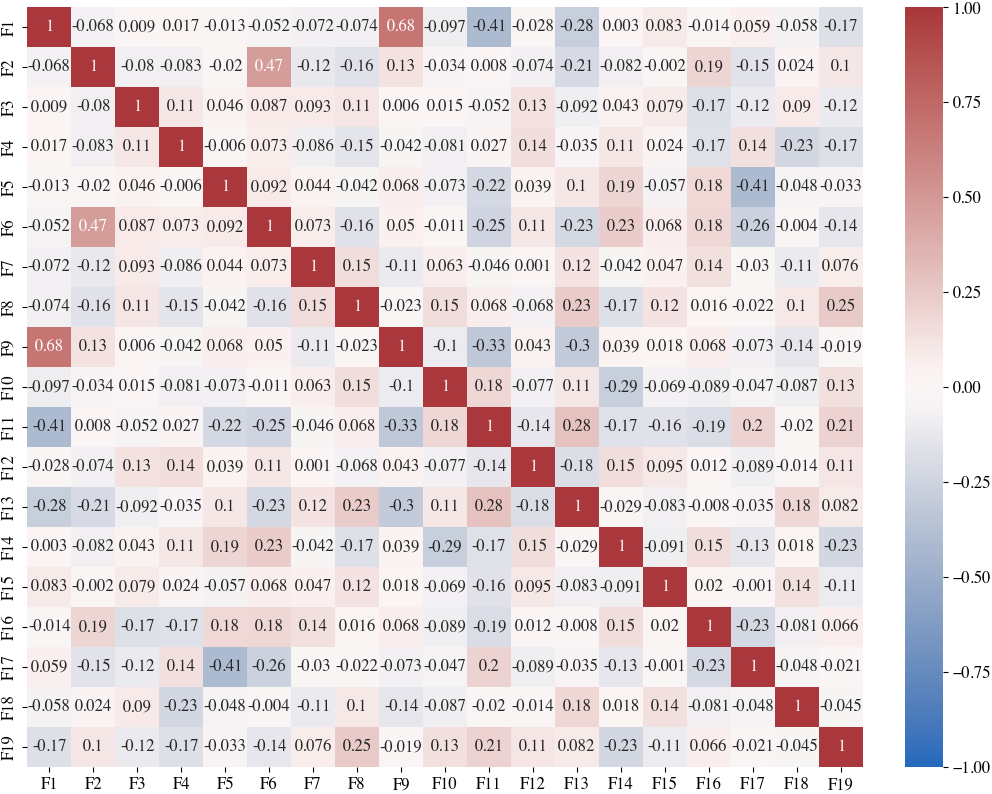

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)

# Assume 'ability_df' is your DataFrame of model abilities from the previous step
# It should have a shape of (n_models, k_factors)

# Calculate the correlation between the ability factors
factor_correlations = ability_df.corr(method='spearman').round(3)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(factor_correlations, annot=True, cmap='vlag', vmin=-1, vmax=1)
plt.savefig("../result/factor-correlations.png", dpi=300, bbox_inches='tight')
plt.show()

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_46481/2855997153.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_46481/2855997153.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()


Created aggregated scenario scores DataFrame with shape: (183, 40)

Dropped 0 scenarios with zero variance: []
Kept 6 scenarios for correlation analysis.


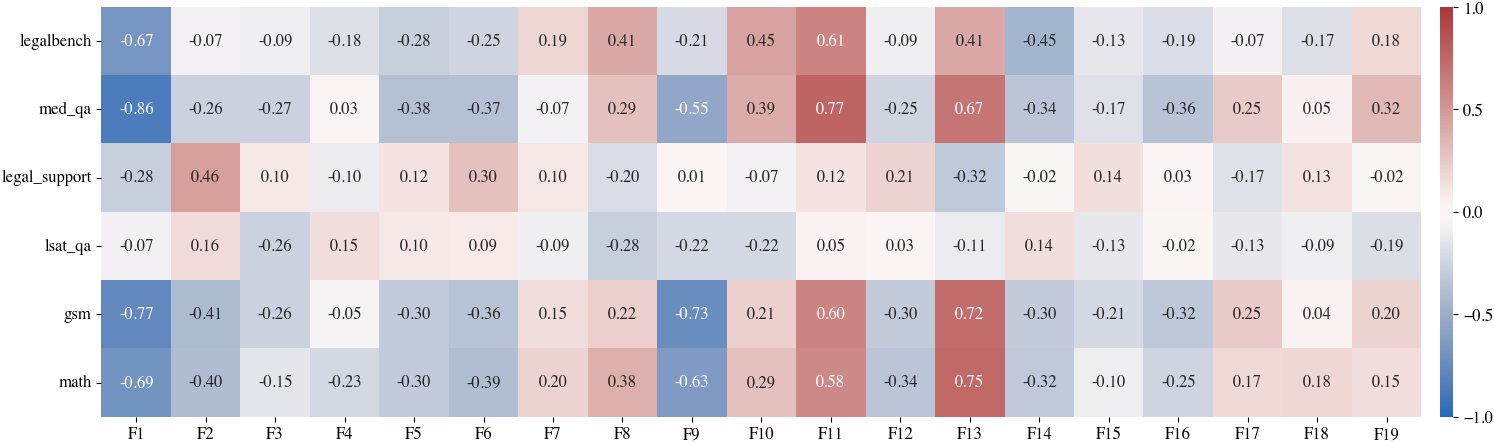

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step A: Aggregate resmat to get per-scenario scores ---
resmat = pd.read_pickle("../data/resmat.pkl")
resmat = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa'])]]
scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
print(f"Created aggregated scenario scores DataFrame with shape: {scenario_scores.shape}")

# --- NEW: Step B: Identify and filter out zero-variance scenarios ---
# Calculate the standard deviation of each scenario's scores
std_devs = scenario_scores.std()

# Find the scenarios where the scores actually vary (std > 0)
scenarios_to_keep = std_devs[std_devs > 0].index
scenarios_dropped = std_devs[std_devs == 0].index

# Create a new DataFrame with only the valid scenarios
scenario_scores_filtered = scenario_scores[scenarios_to_keep]

print(f"\nDropped {len(scenarios_dropped)} scenarios with zero variance: {list(scenarios_dropped)}")
print(f"Kept {len(scenarios_to_keep)} scenarios for correlation analysis.")

# --- Step C: Combine ability scores and the FILTERED scenario scores ---
combined_df = pd.concat([ability_df, scenario_scores_filtered], axis=1)


# --- Step D: Calculate the full correlation matrix ---
full_correlations = combined_df.corr(method='spearman')


# --- Step E: Isolate and visualize the part we care about ---
# We now use the filtered list of columns
factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

# --- Step E: Isolate and visualize with adjusted spacing ---

# 1. Create the figure and axes.
#    Add 'wspace' to control the horizontal gap between the heatmap and color bar.
fig, (ax_heatmap, ax_cbar) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4.5),
    gridspec_kw={
        'width_ratios': [100, 1],
        'wspace': 0.025
    }
)

ax_cbar.set_yticks(np.arange(-1, 1.1, 0.5))
factor_scenario_corr = factor_scenario_corr[[ 'legalbench', 'med_qa', 'legal_support', 'lsat_qa', 'gsm', 'math']]
# 2. Draw the heatmap and color bar (same as before)
sns.heatmap(
    factor_scenario_corr.T,
    annot=True,
    cmap='vlag',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    ax=ax_heatmap,
    cbar_ax=ax_cbar,
    cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}
)

# 3. Set labels (same as before)
ax_heatmap.set_ylabel('')
ax_heatmap.set_xlabel('')

# 4. Save and show the plot
plt.savefig("../result/factor-scenario-correlations.pdf", bbox_inches='tight')
plt.show()

Creating discrimination factors DataFrame...
Created discrimination factors DataFrame with shape: (78712, 19)
Created aggregated scenario discrimination DataFrame with shape: (40, 19)
Filtered to 6 scenarios for analysis

Using mean discrimination factors for each scenario:
scenario_discrimination_filtered shape: (6, 19)
                  F1     F2     F3     F4     F5     F6     F7     F8     F9  \
scenario                                                                       
gsm           -0.620 -0.138 -0.010 -0.034 -0.009 -0.166  0.110 -0.031 -0.636   
legal_support -0.097  0.094 -0.064 -0.106 -0.002  0.040  0.120 -0.027  0.052   
legalbench    -0.168  0.082 -0.039 -0.041 -0.077  0.003  0.054  0.087  0.025   
lsat_qa        0.086  0.096 -0.055 -0.086 -0.005  0.055  0.031 -0.022 -0.467   
math          -0.423 -0.136  0.039 -0.231 -0.051 -0.220  0.189  0.156 -0.604   
med_qa        -0.406  0.037 -0.032  0.047 -0.123 -0.108 -0.050  0.046 -0.196   

                 F10    F11    F12  

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_46481/386033257.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_discrimination = discrimination_df.groupby(level='scenario').mean()


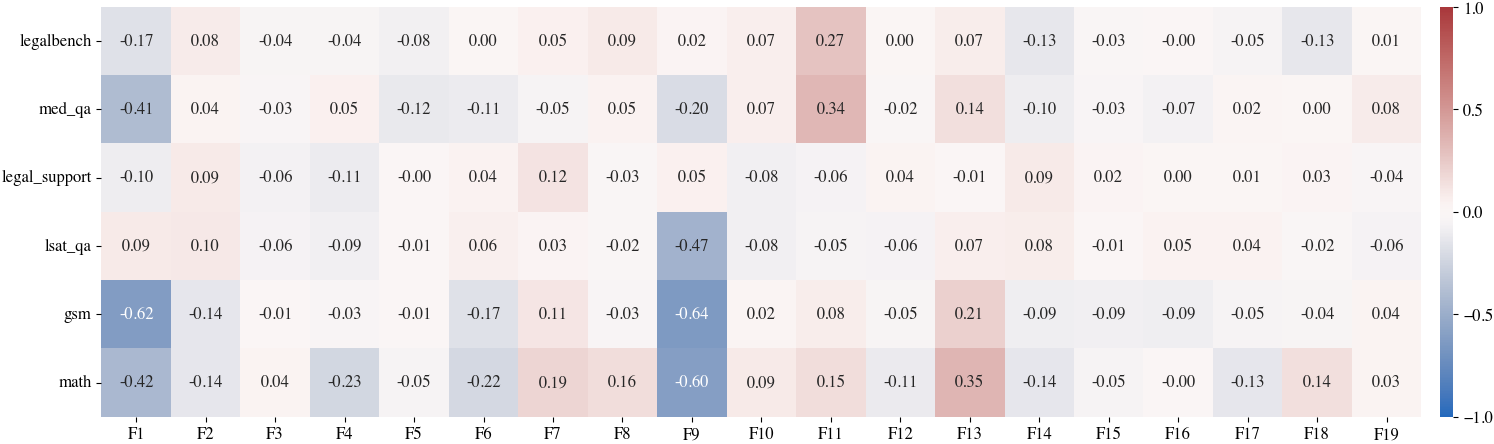


--- Analysis Complete ---
This plot shows mean discrimination factor values for each scenario
- Each cell shows the average discrimination value for that factor in that scenario's items
- Red values = items strongly discriminate on this factor
- Blue values = items weakly discriminate on this factor
- This reveals which cognitive factors are most emphasized in each scenario's items


In [6]:
# EDIT HERE - Correlation plot using discrimination factors (a parameters) instead of ability factors

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Step A: Create a dataframe for discrimination factors (a parameters) ---
# a_for_z_numpy has shape (n_items, k_factors) where n_items = 78712 and k_factors = 19
# We need to map each item to its scenario using resmat column structure

print("Creating discrimination factors DataFrame...")
resmat_full = pd.read_pickle("../data/resmat.pkl")

# Get the item names (column index) and their corresponding scenarios
item_names = resmat_full.columns
factor_names_a = [f'F{i+1}' for i in range(a_for_z_numpy.shape[1])]

# Create DataFrame with discrimination factors
# Each row represents an item, each column represents a factor
discrimination_df = pd.DataFrame(
    a_for_z_numpy, 
    index=item_names, 
    columns=factor_names_a
)

print(f"Created discrimination factors DataFrame with shape: {discrimination_df.shape}")

# --- Step B: Aggregate discrimination factors by scenario ---
# Group by scenario and take the mean of discrimination factors for each scenario
scenario_discrimination = discrimination_df.groupby(level='scenario').mean()
print(f"Created aggregated scenario discrimination DataFrame with shape: {scenario_discrimination.shape}")

# --- Step C: Filter to only include the same scenarios as before ---
scenarios_to_include = ['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa']
scenario_discrimination_filtered = scenario_discrimination.loc[
    scenario_discrimination.index.intersection(scenarios_to_include)
]

print(f"Filtered to {len(scenario_discrimination_filtered)} scenarios for analysis")

# --- Step D: Use the mean discrimination factors directly ---
# No need for correlation - just show the mean F values for each scenario

print("\nUsing mean discrimination factors for each scenario:")
print(f"scenario_discrimination_filtered shape: {scenario_discrimination_filtered.shape}")
print(scenario_discrimination_filtered.round(3))

# Transpose to match the original plot format (scenarios as rows, factors as columns)
discrimination_matrix = scenario_discrimination_filtered

# --- Step E: Create the visualization ---
fig, (ax_heatmap, ax_cbar) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4.5),
    gridspec_kw={
        'width_ratios': [100, 1],
        'wspace': 0.025
    }
)

# Reorder rows to match the previous plot
scenario_order = ['legalbench', 'med_qa', 'legal_support', 'lsat_qa', 'gsm', 'math']
discrimination_matrix_ordered = discrimination_matrix.reindex(scenario_order)

# Create the heatmap
sns.heatmap(
    discrimination_matrix_ordered,
    annot=True,
    cmap='vlag',
    vmin=-1,
    vmax=1,
    center=0,
    fmt='.2f',
    ax=ax_heatmap,
    cbar_ax=ax_cbar,
    cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}
)

# Set labels
ax_heatmap.set_ylabel('')
ax_heatmap.set_xlabel('')

# Save and show the plot
plt.savefig("../result/discrimination-factor-means-by-scenario.pdf", bbox_inches='tight')
plt.show()

print("\n--- Analysis Complete ---")
print("This plot shows mean discrimination factor values for each scenario")
print("- Each cell shows the average discrimination value for that factor in that scenario's items")
print("- Red values = items strongly discriminate on this factor")
print("- Blue values = items weakly discriminate on this factor") 
print("- This reveals which cognitive factors are most emphasized in each scenario's items")

In [7]:
# Debug cell - Let's check what's happening step by step

# First, let's check if we have the right variables available
print("Available variables check:")
print(f"a_for_z_numpy shape: {a_for_z_numpy.shape}")
print(f"scenario_scores_filtered available: {'scenario_scores_filtered' in locals()}")

# If scenario_scores_filtered is not available, let's recreate it
if 'scenario_scores_filtered' not in locals():
    print("Recreating scenario_scores_filtered...")
    # Step A: Aggregate resmat to get per-scenario scores
    resmat = pd.read_pickle("../data/resmat.pkl")
    resmat = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa'])]]
    scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
    
    # Step B: Filter out zero-variance scenarios
    std_devs = scenario_scores.std()
    scenarios_to_keep = std_devs[std_devs > 0].index
    scenario_scores_filtered = scenario_scores[scenarios_to_keep]
    print(f"Recreated scenario_scores_filtered with shape: {scenario_scores_filtered.shape}")

print("\nNow let's check the discrimination factors:")
resmat_full = pd.read_pickle("../data/resmat.pkl")
item_names = resmat_full.columns
factor_names_a = [f'F{i+1}' for i in range(a_for_z_numpy.shape[1])]

# Create discrimination DataFrame
discrimination_df = pd.DataFrame(
    a_for_z_numpy, 
    index=item_names, 
    columns=factor_names_a
)

print(f"discrimination_df shape: {discrimination_df.shape}")

# Group by scenario and take mean
scenario_discrimination = discrimination_df.groupby(level='scenario').mean()
print(f"scenario_discrimination shape: {scenario_discrimination.shape}")
print("Available scenarios in discrimination data:")
print(scenario_discrimination.index.tolist())

# Filter to match our target scenarios
scenarios_to_include = ['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa']
scenario_discrimination_filtered = scenario_discrimination.loc[
    scenario_discrimination.index.intersection(scenarios_to_include)
]

print(f"\nFiltered discrimination data shape: {scenario_discrimination_filtered.shape}")
print("Scenarios in filtered discrimination data:")
print(scenario_discrimination_filtered.index.tolist())
print("Scenarios in filtered scores data:")
print(scenario_scores_filtered.index.tolist())

# Check for data alignment issues
print("\nSample discrimination values (first 3 factors, first 3 scenarios):")
print(scenario_discrimination_filtered.iloc[:3, :3])

print("\nSample scenario scores (first 3 scenarios):")
print(scenario_scores_filtered.iloc[:3])


Available variables check:
a_for_z_numpy shape: (78712, 19)
scenario_scores_filtered available: True

Now let's check the discrimination factors:
discrimination_df shape: (78712, 19)
scenario_discrimination shape: (40, 19)
Available scenarios in discrimination data:
['air_bench_2024', 'babi_qa', 'bbq', 'blimp', 'bold', 'boolq', 'civil_comments', 'code', 'commonsense', 'copyright', 'disinfo', 'dyck_language_np=3', 'entity_data_imputation', 'entity_matching', 'gsm', 'ice', 'imdb', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'med_qa', 'mmlu', 'msmarco', 'narrative_qa', 'natural_qa', 'quac', 'raft', 'real_toxicity_prompts', 'summarization_cnndm', 'summarization_xsum', 'synthetic_efficiency', 'synthetic_reasoning', 'synthetic_reasoning_natural', 'thai_exam', 'the_pile', 'truthful_qa', 'twitter_aae', 'wikifact', 'wmt_14']

Filtered discrimination data shape: (6, 19)
Scenarios in filtered discrimination data:
['gsm', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'med_qa']
Scenarios 

/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_46481/2291025550.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_discrimination = discrimination_df.groupby(level='scenario').mean()


=== Alternative Approach: Discrimination Factor Profiles by Scenario ===


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_46481/3906600148.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scenario_discrimination = discrimination_df.groupby(level='scenario').mean()


Discrimination profiles shape: (6, 19)

Sample discrimination profiles:
                  F1     F2     F3     F4     F5     F6     F7     F8     F9  \
scenario                                                                       
legalbench    -0.168  0.082 -0.039 -0.041 -0.077  0.003  0.054  0.087  0.025   
med_qa        -0.406  0.037 -0.032  0.047 -0.123 -0.108 -0.050  0.046 -0.196   
legal_support -0.097  0.094 -0.064 -0.106 -0.002  0.040  0.120 -0.027  0.052   
lsat_qa        0.086  0.096 -0.055 -0.086 -0.005  0.055  0.031 -0.022 -0.467   
gsm           -0.620 -0.138 -0.010 -0.034 -0.009 -0.166  0.110 -0.031 -0.636   
math          -0.423 -0.136  0.039 -0.231 -0.051 -0.220  0.189  0.156 -0.604   

                 F10    F11    F12    F13    F14    F15    F16    F17    F18  \
scenario                                                                       
legalbench     0.068  0.274  0.000  0.072 -0.126 -0.029 -0.002 -0.051 -0.126   
med_qa         0.066  0.338 -0.023  0.142 -0.09

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

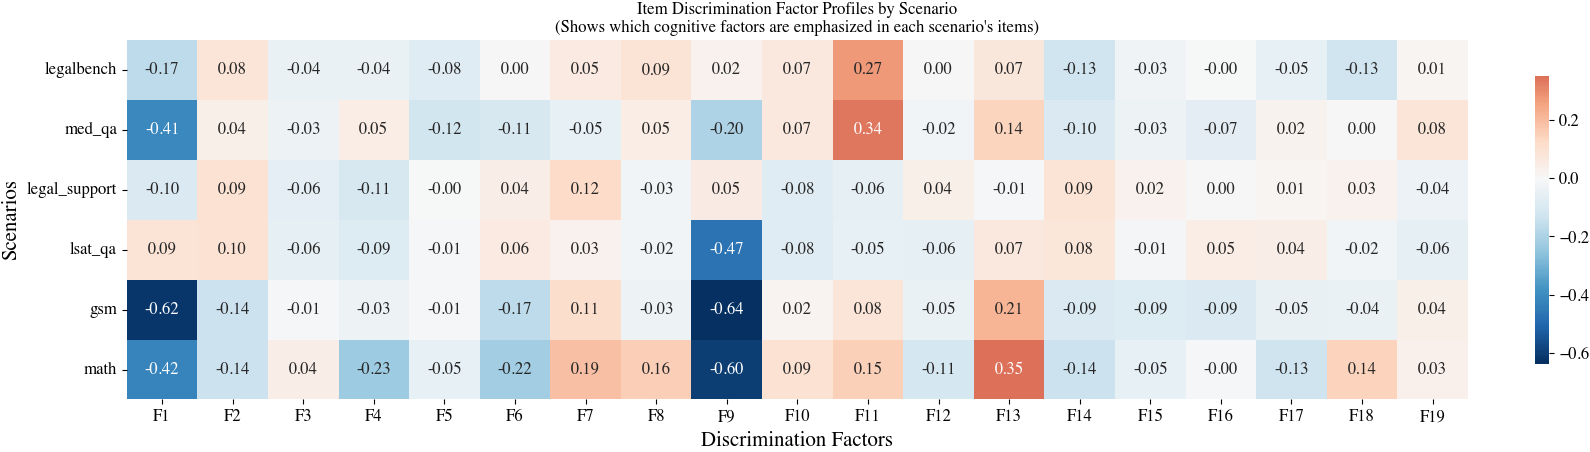

In [8]:
# ALTERNATIVE APPROACH: Compare discrimination factor patterns across scenarios
# This shows which cognitive factors (as measured by item discrimination) are emphasized in each scenario

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("=== Alternative Approach: Discrimination Factor Profiles by Scenario ===")

# Create the discrimination factors DataFrame (same as before)
resmat_full = pd.read_pickle("../data/resmat.pkl")
item_names = resmat_full.columns
factor_names_a = [f'F{i+1}' for i in range(a_for_z_numpy.shape[1])]

discrimination_df = pd.DataFrame(
    a_for_z_numpy, 
    index=item_names, 
    columns=factor_names_a
)

# Aggregate by scenario (mean discrimination factors per scenario)
scenario_discrimination = discrimination_df.groupby(level='scenario').mean()

# Filter to our scenarios of interest
scenarios_to_include = ['legal_support', 'lsat_qa', 'gsm', 'math', 'legalbench', 'med_qa']
scenario_discrimination_filtered = scenario_discrimination.loc[
    scenario_discrimination.index.intersection(scenarios_to_include)
]

print(f"Discrimination profiles shape: {scenario_discrimination_filtered.shape}")

# Reorder scenarios to match previous plots
scenario_order = ['legalbench', 'med_qa', 'legal_support', 'lsat_qa', 'gsm', 'math']
scenario_discrimination_ordered = scenario_discrimination_filtered.reindex(scenario_order)

print("\nSample discrimination profiles:")
print(scenario_discrimination_ordered.round(3))

# Create the heatmap showing discrimination factor profiles
fig, ax = plt.subplots(figsize=(15, 4))

sns.heatmap(
    scenario_discrimination_ordered,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f',
    ax=ax,
    cbar_kws={'shrink': .8}
)

ax.set_title('Item Discrimination Factor Profiles by Scenario\n(Shows which cognitive factors are emphasized in each scenario\'s items)')
ax.set_xlabel('Discrimination Factors')
ax.set_ylabel('Scenarios')

plt.tight_layout()
plt.savefig("../result/discrimination-factor-profiles-by-scenario.pdf", bbox_inches='tight')
plt.show()

print("\n=== Interpretation ===")
print("This heatmap shows:")
print("- Which cognitive factors (F1-F19) are most emphasized in each scenario's items")
print("- Positive values (red) = items in this scenario strongly discriminate on this factor")
print("- Negative values (blue) = items in this scenario weakly discriminate on this factor")
print("- This reveals the cognitive profile of each scenario's item set")



--- Generating Bar Chart Profiles for Each Scenario ---


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_89093/2928285677.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=2.0)


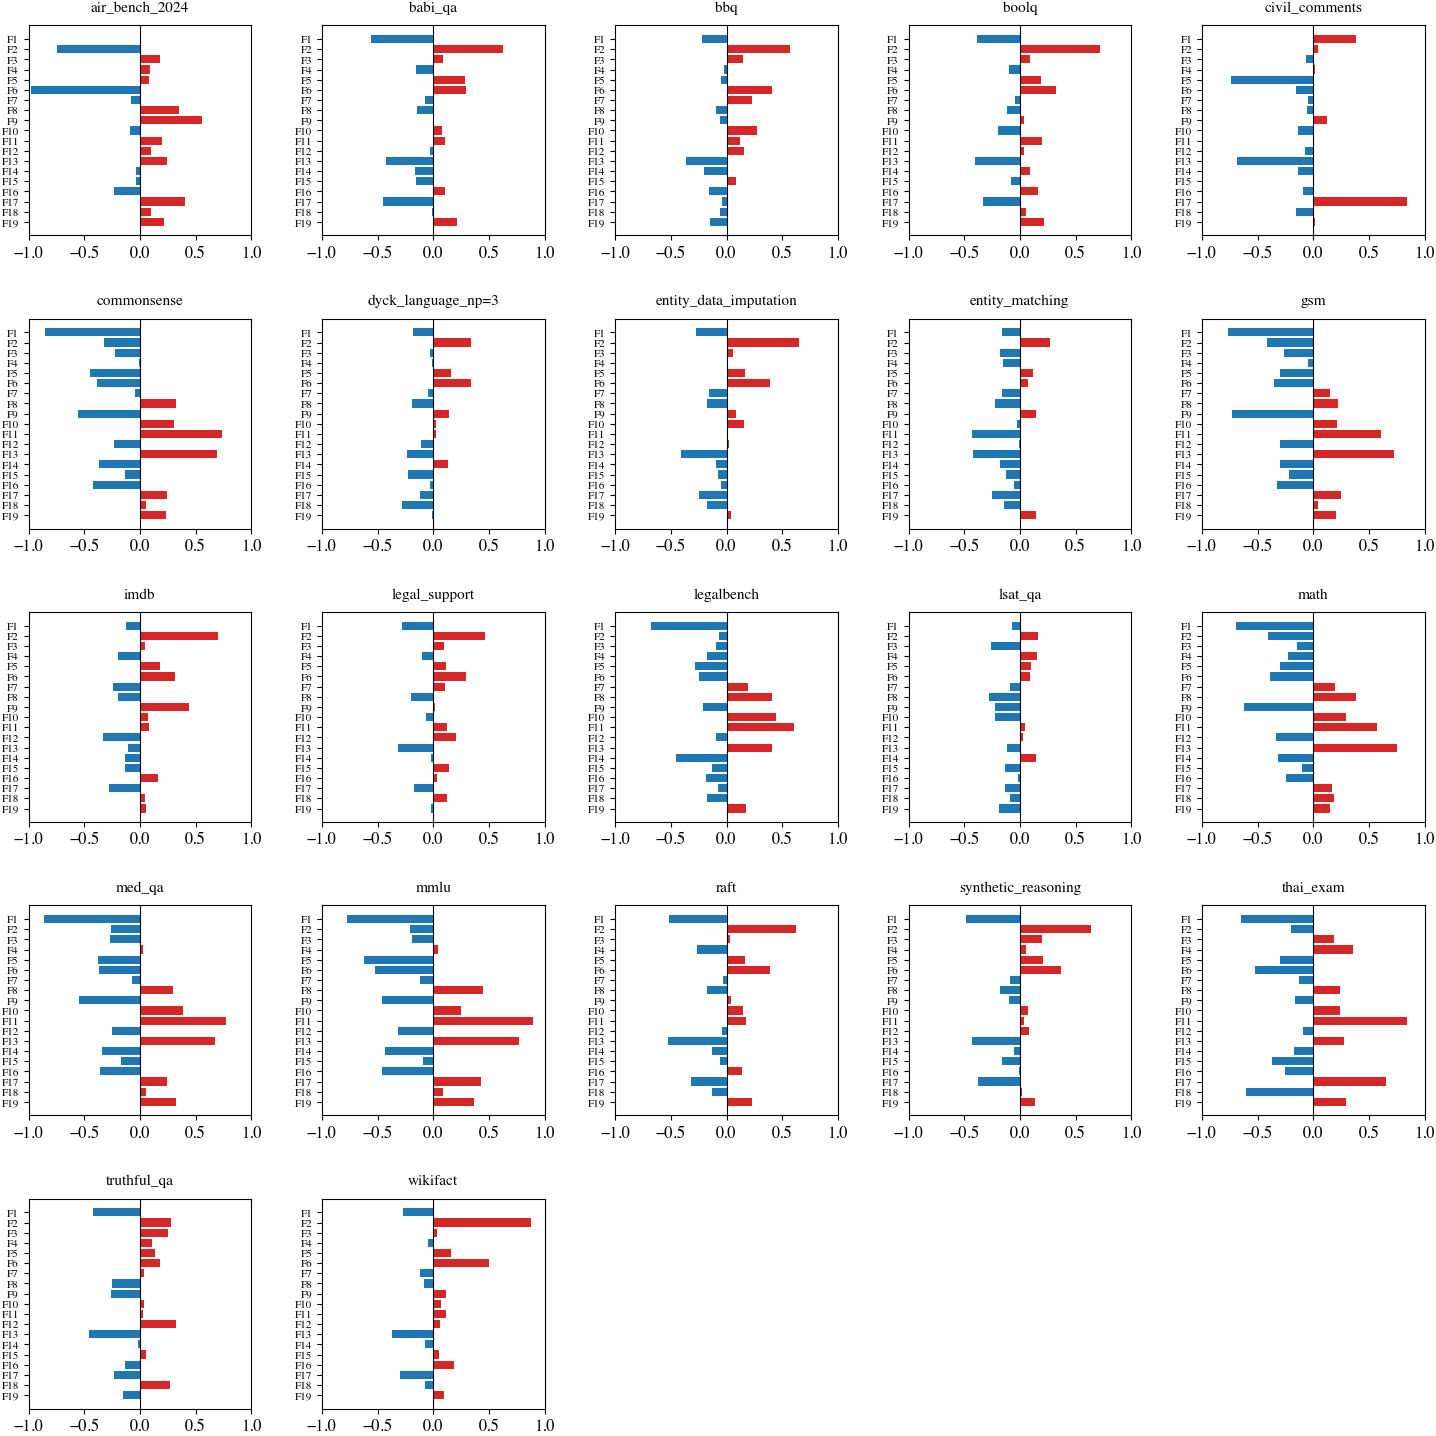

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

# ===================================================================
# == NEW: Code to Generate Bar Chart Profiles
# ===================================================================

def plot_correlation_bars(ax, values, labels, title):
    """Helper function to draw a horizontal bar chart of correlations."""
    y_pos = np.arange(len(labels))
    
    # Create colors: red for positive, blue for negative
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in values]
    
    # Plot the bars
    ax.barh(y_pos, values, color=colors)
    
    # Set labels and title
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()  # labels read top-to-bottom
    # ax.set_xlabel('Spearman Correlation', fontsize=8)
    ax.set_title(title, size=11, pad=10)
    
    # Set x-axis limits and add a vertical line at zero
    ax.set_xlim(-1.0, 1.0)
    ax.axvline(0, color='black', linewidth=0.8)


# --- Main Plotting Logic ---
factors = factor_scenario_corr.index.tolist()
scenarios = factor_scenario_corr.columns.tolist()
num_scenarios = len(scenarios)

# Create a grid of subplots (NOT polar this time)
num_cols = 5
num_rows = int(np.ceil(num_scenarios / num_cols))

fig, axes = plt.subplots(figsize=(15, num_rows * 3), nrows=num_rows, ncols=num_cols)

print("\n--- Generating Bar Chart Profiles for Each Scenario ---")

axes_flat = axes.flatten()

# Loop through each scenario and draw its chart
for i, scenario in enumerate(scenarios):
    ax = axes_flat[i]
    values = factor_scenario_corr[scenario].tolist()
    plot_correlation_bars(ax, values, factors, scenario)

# Hide any unused subplots
for i in range(num_scenarios, len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig("../result/factor-scenario-bar-profiles.png", dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import numpy as np

real_eigenvalues = np.load("../result/PA/real_eigenvalues.npy")
percentile_eigenvalues = np.load("../result/PA/percentile_eigenvalues.npy")
n_factors_parallel = int(np.load("../result/PA/n_factors_parallel.npy")[0])
n_components = 182

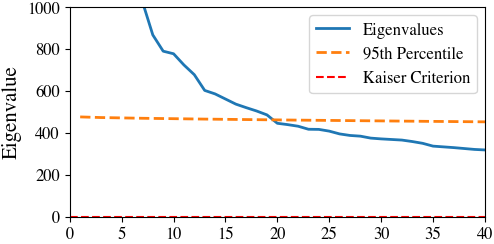

In [2]:
import sys, os
import matplotlib.pyplot as plt
sys.path.append('..') 
import style
plt.rcParams.update(style.rcparams)
# --- 7. Generate the Final Scree Plot ---
plt.figure(figsize=(5, 2.5))
x_values = range(1, n_components + 1)

plt.plot(x_values, real_eigenvalues, '-', linewidth=2, label='Eigenvalues')
plt.plot(x_values, percentile_eigenvalues, '--', linewidth=2, label='95th Percentile')
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion')

# plt.title('Corrected Scree Plot (on Normalized Data)')
# plt.xlabel('Principal Component Number')
plt.ylabel('Eigenvalue')
# plt.yscale('log')
# plt.grid()
plt.legend()
# Focus on the most important part of the plot
plt.xlim(0, 40)
# plt.ylim(0, max(real_eigenvalues[1:])*1.5) # Zoom in, ignoring the first factor for scale
plt.ylim(0, 1000)

# Save the plot
output_dir = "../result"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig(os.path.join(output_dir, "corrected_scree_plot.pdf"), bbox_inches='tight')
plt.show()

MIRT AUC: 0.89363 ± 0.00052


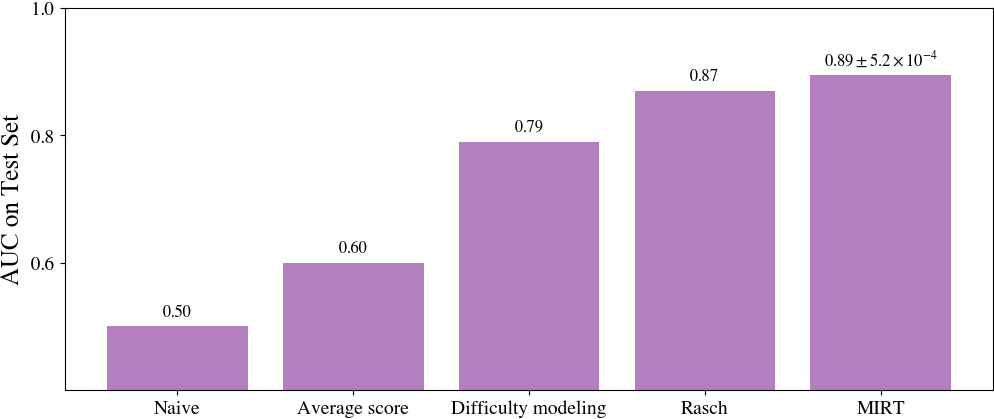

In [13]:
import sys
import matplotlib.pyplot as plt
sys.path.append('..') 
import style
mirt_runs = [0.893350791, 0.893389648, 0.893980013, 0.894449958, 0.892994953]
import numpy as np
mean_mirt = np.mean(mirt_runs)
std_mirt = np.std(mirt_runs)

print(f"MIRT AUC: {mean_mirt:.5f} ± {std_mirt:.5f}")

plt.rcParams.update(style.rcparams)
values = [0.5, 0.6, 0.79, 0.87, mean_mirt]
labels = ['Naive', 'Average score', 'Difficulty modeling', 'Rasch', 'MIRT']

fig, ax = plt.subplots(figsize=(10, 4.25))
bars = ax.bar(labels, values, color='#b37fbf')

# ax.set_xlabel(r'Response Model', fontsize=15)
ax.set_ylabel(r'AUC on Test Set', fontsize=18)
ax.set_ylim(0.4, 1)
ax.set_yticks([i/5 for i in range(3, 6)])
# ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tick_params(axis="both", labelsize=14)

for i, (bar, v) in enumerate(zip(bars, values)):
    if labels[i] == 'MIRT':
        label_text = r'$0.89\pm5.2\times 10^{-4}$'
    else:
        label_text = f'{v:.2f}'
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, label_text, color='black',
            ha='center', va='bottom', fontsize=12)

plt.savefig("../result/test_auc_grow.pdf", bbox_inches="tight")
plt.show()